In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import matplotlib.cm as cm
import colormaps as cmaps
import matplotlib.colors as colors
from labellines import labelLines
from matplotlib.cm import brg, ScalarMappable
from matplotlib.colors import (
    LogNorm,
    TwoSlopeNorm,
    LinearSegmentedColormap,
    Normalize,
    ListedColormap,
)
from matplotlib.lines import Line2D

import jax

# plt.rcParams.update(
# {"text.usetex": True, "font.family": "Helvetica", "font.size": 8}
# )

plt.rcParams.update(
    {
        "text.usetex": False,
        "font.family": "sans-serif",
        "font.sans-serif": ["Calibri"],
        "font.size": 10,
        "mathtext.fontset": "cm",
    }
)

gnuplot_barve = cm.gnuplot2_r(np.linspace(0.3, 1, 10))
gnuplot_custom = LinearSegmentedColormap.from_list("gnuplot_custom", gnuplot_barve)

brg_barve = cmaps.guppy(np.linspace(0, 1, 10))
bgr_custom = LinearSegmentedColormap.from_list("bgr_custom", brg_barve)

YlGn_barve = cm.YlGn(np.linspace(0, 0.8, 10))
ylgn_custom = LinearSegmentedColormap.from_list("ylgn_custom", YlGn_barve)

markers = ["o", "D", "^", "x", "v", "<", ">", "p", "*", "X"]

set1_list = [
    "#e41a1c",
    "#377eb8",
    "#4daf4a",
    "#984ea3",
    "#ff7f00",
    "#f781bf",
    "#999999",
    "#a65628",
]
bold_list = [
    "#7f3c8d",
    "#11a579",
    "#3969ac",
    "#e73f74",
    "#f2b701",
    "#80ba5a",
    "#e68310",
    "#008695",
    "#cf1c90",
    "#f97b72",
    "#a5aa99",
]

OUT = "/home/kzeleznikar/IJS-F1/Koda/toymodels/plots/"

W = 5.0
from utils import newfig, fd

import utils as ut
import ei_open_loop as eol
import ei_unified as eu
import ei_jax as ej

In [2]:
nk = 15

bd = eu.tb_2d(
    nk=nk,
    gap=1.0,
    ta=1.0,
    tb=-0.3,
)

p = eu.MFPars(
    v=5.0,
    n=1.0,
    uh=None,
)

ti = 0.25

se = eu.solve_eq(
    bd, p,
    t=ti,
    d=0.8,
    m=0.0,
    mix=(0.15, 0.15),
    tol=1.0e-10,
    nmax=10000,
    chk=20,
    prog=True,
)

ni = se.n.copy()
# mu0 = se.mu


Equilibrium EI:   0%|          | 0/10000 [00:00<?, ?it/s]

In [33]:
nk = 20

bd = eu.tb_2d(
    nk=nk,
    gap=1.0,
    ta=1.0,
    tb=-0.3,
)

p = eu.MFPars(
    v=5.0,
    n=1.0,
    uh=0.5,
)

s0 = eu.solve_eq(
    bd, p,
    t=0.0,
    d=1.0,
    m=0.0,
    mix=(0.15, 0.15),
    tol=1.0e-10,
    nmax=20000,
    chk=20,
    prog=True,
)

mu0 = s0.mu
d0 = abs(s0.d)

tc = eu.critical_temperature(
    bd, p,
    tlo=1.0e-4,
    thi=2.0,
    tol=1.0e-7,
    nmax=100,
    prog=True,
)

print("Delta_0 =", d0)
print("T_c     =", tc)
print("mu0     =", mu0)

Equilibrium EI:   0%|          | 0/20000 [00:00<?, ?it/s]

kriticna temp bisekcija:   0%|          | 0/100 [00:00<?, ?it/s]

Delta_0 = 2.174674669808321
T_c     = 1.0631439346745613
mu0     = 1.7898805783820941


In [34]:
nt = 10

tn = np.linspace(0.03, 2.0, nt)
t1a = tn * tc
t2a = tn * tc

In [35]:
mua = np.empty(nt)
sea = []

de = s0.d
me = s0.m

for q in tqdm(range(nt), desc="Equilibrium references"):
    sq = eu.solve_eq(
        bd,
        p,
        t=t1a[q],
        d=max(abs(de), 1.0e-6),
        m=me,
        mix=(0.15, 0.15),
        tol=1.0e-9,
        nmax=20000,
        chk=20,
        prog=False,
    )

    mua[q] = sq.mu
    sea.append(sq)

    de = sq.d
    me = sq.m


Equilibrium references: 100%|██████████| 10/10 [00:01<00:00,  6.79it/s]


In [36]:
print(np.mean(mua[:-len(mua)//2]))
mu_B= np.mean(mua[:-len(mua)//2])


0.1933756880696269


In [37]:
mua = np.empty(nt)
sea = [None] * nt

de = s0.d
me = s0.m

wc = np.inf

da = np.full((nt, nt), np.nan)
ma = np.full((nt, nt), np.nan)
er = np.full((nt, nt), np.nan)
it = np.zeros((nt, nt), dtype=int)
ok = np.zeros((nt, nt), dtype=bool)

de = s0.d
me = s0.m

for j in tqdm(range(nt), desc="T2 rows"):
    t2 = t2a[j]

    # Cheap equilibrium seed along the diagonal
    se = eu.solve_eq(
        bd, p,
        t=t2,
        d=max(abs(de), 1.0e-6),
        m=me,
        mix=(0.15, 0.15),
        tol=1.0e-9,
        nmax=20000,
        chk=20,
        prog=False,
    )

    de = se.d
    me = se.m

    n = se.n.copy()
    d = se.d
    m = se.m

    for i in tqdm(
        range(j, nt),
        desc="T1 columns",
        leave=False,
    ):
        t1 = t1a[i]

        kaa = 0.1
        kab = 0.2
        kbb = 0.1

        bs = (
            ej.gam_db(
                t1,
                kap=(kaa, kab, kbb),
                wc=wc,
                mu = mu_B,
                name="bath 1",
            ),
            ej.gam_db(
                t2,
                kap=(kaa, kab, kbb),
                wc=wc,
                mu= mu_B,
                name="bath 2",
            ),
        )

        so = ej.solve_open(
            bd, p,
            n,
            bs,
            d=d,
            m=m,
            dt=0.8,
            td=0.3,
            tm=0.3,
            tol=1.0e-7,
            nmax=20000,
            chk=20,
            prog=False,
            mode="block",
            block=512,
        )

        ds = 1.0 * d0

        da[j, i] = abs(so.d)
        ma[j, i] = so.m
        er[j, i] = so.err
        it[j, i] = so.it
        ok[j, i] = so.ok

        n = so.n.copy()
        d = max(abs(so.d), ds)
        m = so.m

        da[i, j] = da[j, i]
        ma[i, j] = ma[j, i]
        er[i, j] = er[j, i]
        it[i, j] = it[j, i]
        ok[i, j] = ok[j, i]

T2 rows: 100%|██████████| 10/10 [00:08<00:00,  1.13it/s]


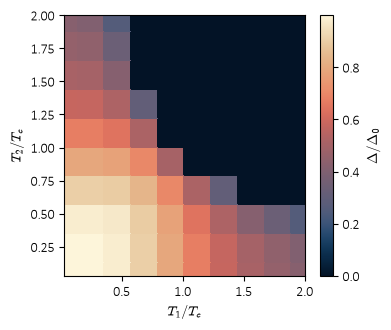

Converged: 95 / 100
Largest residual: 4.18390118284151e-06
Largest iteration count: 20000


In [38]:
z = da / d0

h = 0.85
fig, ax = plt.subplots(figsize=(4, h * 4))

im = ax.pcolormesh(
    tn,
    tn,
    z,
    shading="auto",
    cmap=cmaps.lipari,
    vmin=0.0,
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$\Delta/\Delta_0$", rotation=90, labelpad=5)

ax.set_xlabel(r"$T_1/T_c$")
ax.set_ylabel(r"$T_2/T_c$")
ax.set_xlim(tn.min(), tn.max())
ax.set_ylim(tn.min(), tn.max())

plt.tight_layout()
# plt.savefig("EI_V=3_G=2_tb2d_prodbath_gapcmap_jax.pdf")
plt.show()

print("Converged:", np.count_nonzero(ok), "/", ok.size)
print("Largest residual:", np.nanmax(er))
print("Largest iteration count:", np.max(it))

1d sweep mu test za f(1-f)

In [9]:
nt1 = 100

t1n = np.linspace(1.10, 1.35, nt1)
t1a = t1n * tc

t2 = 0.05 * tc


dsx = 0.03 * d0
kaa = 0.05
kab = 0.6
kbb = 0.05

wc = np.inf
ds = 0.04 * d0

In [27]:
mua = np.empty(nt1)

de = s0.d
me = s0.m

for q in tqdm(
    range(nt1),
    desc="Equilibrium references",
):
    sq = eu.solve_eq(
        bd,
        p,
        t=t1a[q],
        d=max(abs(de), 1.0e-6),
        m=me,
        mix=(0.15, 0.15),
        tol=1.0e-9,
        nmax=20000,
        chk=20,
        prog=False,
    )

    mua[q] = sq.mu

    de = sq.d
    me = sq.m

mu_m = np.mean(mua)

print("Minimum equilibrium mu:", mua.min())
print("Maximum equilibrium mu:", mua.max())
print("Mean equilibrium mu:", mu_m)

Equilibrium references: 100%|██████████| 100/100 [00:24<00:00,  4.01it/s]

Minimum equilibrium mu: 1.7601107388864432
Maximum equilibrium mu: 1.9134378970349801
Mean equilibrium mu: 1.8386412051633638


In [26]:
se2 = eu.solve_eq(
    bd,
    p,
    t=t2,
    d=max(abs(s0.d), ds),
    m=s0.m,
    mix=(0.15, 0.15),
    tol=1.0e-9,
    nmax=20000,
    chk=20,
    prog=True,
)

Equilibrium EI:   0%|          | 0/20000 [00:00<?, ?it/s]

In [28]:
fa = np.linspace(0.95, 1.2, 10)

muba = fa * mu_m

In [29]:
dg = np.full(
    (fa.size, nt1),
    np.nan,
)

eg = np.full(
    (fa.size, nt1),
    np.nan,
)

og = np.zeros(
    (fa.size, nt1),
    dtype=bool,
)

for q in tqdm(
    range(fa.size),
    desc="Chemical potentials",
):
    mu_b = muba[q]

    n = se2.n.copy()
    d = max(abs(se2.d), ds)
    m = se2.m

    for i in tqdm(
        range(nt1),
        desc="T1 sweep",
        leave=False,
    ):
        t1 = t1a[i]

        bs = (
            ej.gam_db(
                t1,
                kap=(kaa, kab, kbb),
                wc=wc,
                mu=mu_b,
                name="bath 1",
            ),
            ej.gam_db(
                t2,
                kap=(kaa, kab, kbb),
                wc=wc,
                mu=mu_b,
                name="bath 2",
            ),
        )

        so = ej.solve_open(
            bd,
            p,
            n,
            bs,
            d=d,
            m=m,
            dt=0.4,
            td=0.5,
            tm=0.5,
            tol=1.0e-5,
            nmax=30000,
            chk=20,
            prog=False,
            mode="block",
            block=512,
        )

        dg[q, i] = abs(so.d) / d0
        eg[q, i] = so.err
        og[q, i] = so.ok

        n = so.n.copy()
        d = max(abs(so.d), ds)
        m = so.m

Chemical potentials: 100%|██████████| 10/10 [00:53<00:00,  5.34s/it]


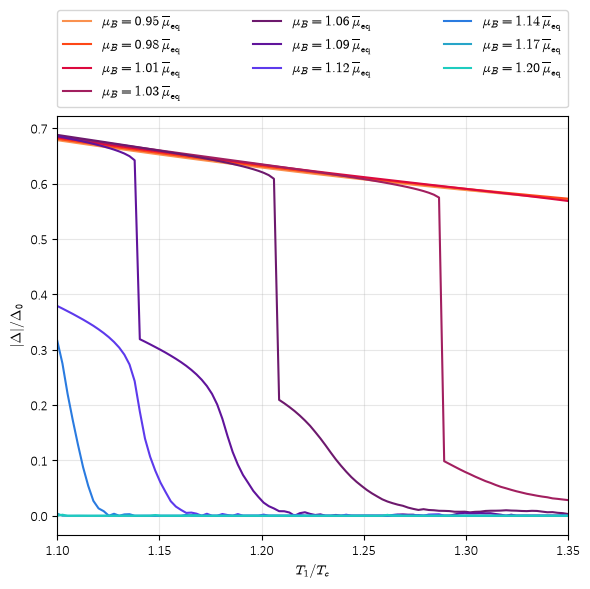

In [30]:
h = 1
fig, ax = plt.subplots(
    figsize=(6, h * 6)
)

for q in range(fa.size):
    y = np.where(
        og[q],
        dg[q],
        np.nan,
    )

    ax.plot(
        t1n,
        y,
        color=brg_barve[q],
        label=rf"$\mu_B={fa[q]:.2f}\,\overline{{\mu}}_{{\rm eq}}$",
    )

ax.set_xlabel(r"$T_1/T_c$")
ax.set_ylabel(r"$|\Delta|/\Delta_0$")

ax.set_xlim(t1n[0], t1n[-1])

ax.grid(alpha=0.3)

ax.legend(
    bbox_to_anchor=(0, 1.02, 1, 0.2),
    loc="lower left",
    mode="expand",
    borderaxespad=0,
    ncol=3,
)

plt.tight_layout()

In [17]:
xa = np.linspace(1.05, 1.15, 100)

t2 = 0.05 * tc
mu_b = 1.1 * mu_m

dsx = 0.03 * d0

In [18]:
def run_path(xa, n, d, m, desc):
    za = np.full(xa.size, np.nan)
    ea = np.full(xa.size, np.nan)
    oa = np.zeros(xa.size, dtype=bool)

    sl = None

    for q in tqdm(
        range(xa.size),
        desc=desc,
    ):
        t1 = xa[q] * tc

        bs = (
            ej.gam_db(
                t1,
                kap=(kaa, kab, kbb),
                wc=wc,
                mu=mu_b,
                name="bath 1",
            ),
            ej.gam_db(
                t2,
                kap=(kaa, kab, kbb),
                wc=wc,
                mu=mu_b,
                name="bath 2",
            ),
        )

        sl = ej.solve_open(
            bd,
            p,
            n,
            bs,
            d=d,
            m=m,
            dt=0.2,
            td=0.8,
            tm=0.8,
            tol=1.0e-6,
            nmax=100000,
            chk=50,
            prog=False,
        )

        za[q] = abs(sl.d) / d0
        ea[q] = sl.err
        oa[q] = sl.ok

        n = sl.n.copy()
        d = max(abs(sl.d), dsx)
        m = sl.m

    return za, ea, oa, sl

In [21]:
zf, ef, of, sf = run_path(
    xa,
    se2.n.copy(),
    max(abs(se2.d), 0.1 * d0),
    se2.m,
    "Increasing T1",
)

zr, erx, orx, sr = run_path(
    xa[::-1],
    sf.n.copy(),
    max(abs(sf.d), dsx),
    sf.m,
    "Decreasing T1",
)

zr = zr[::-1]
erx = erx[::-1]
orx = orx[::-1]

Decreasing T1: 100%|██████████| 100/100 [00:08<00:00, 11.30it/s]


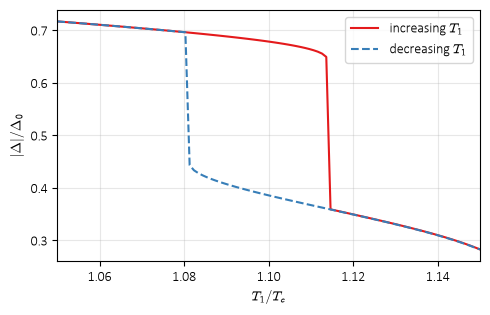

In [22]:
h = 0.65
fig, ax = plt.subplots(
    figsize=(5, h * 5)
)

ax.plot(
    xa,
    np.where(of, zf, np.nan),
    color=set1_list[0],
    label=r"increasing $T_1$",
)

ax.plot(
    xa,
    np.where(orx, zr, np.nan),
    color=set1_list[1],
    linestyle="--",
    label=r"decreasing $T_1$",
)

ax.set_xlabel(r"$T_1/T_c$")
ax.set_ylabel(r"$|\Delta|/\Delta_0$")

ax.set_xlim(xa[0], xa[-1])

ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()

In [31]:
x0 = 1.09
t1 = x0 * tc

bs = (
    ej.gam_db(
        t1,
        kap=(kaa, kab, kbb),
        wc=wc,
        mu=mu_b,
        name="bath 1",
    ),
    ej.gam_db(
        t2,
        kap=(kaa, kab, kbb),
        wc=wc,
        mu=mu_b,
        name="bath 2",
    ),
)

dsa = d0 * np.array(
    [
        0.001,
        0.002,
        0.2,
        0.5,
        1.0,
    ]
)

za = []

for di in tqdm(
    dsa,
    desc="Initial gap test",
):
    sx = ej.solve_open(
        bd,
        p,
        se2.n.copy(),
        bs,
        d=di,
        m=se2.m,
        dt=0.2,
        td=0.8,
        tm=0.8,
        tol=3.0e-6,
        nmax=100000,
        chk=50,
        prog=False,
        mode="block",
        block=512,
    )

    za.append(
        (
            di / d0,
            abs(sx.d) / d0,
            sx.err,
            sx.it,
            sx.ok,
        )
    )

for z in za:
    print(z)

Initial gap test: 100%|██████████| 5/5 [00:03<00:00,  1.36it/s]

(np.float64(0.001), 0.0024981633780400228, 5.476176738739014e-07, 7800, True)
(np.float64(0.002), 0.0024991994492851275, 1.2570526450872421e-06, 7900, True)
(np.float64(0.2), 0.002673650284136432, 2.1134037524461746e-06, 8250, True)
(np.float64(0.5), 0.0024981632047839618, 5.122274160385132e-07, 8400, True)
(np.float64(1.0), 0.0024997990885124366, 1.5245750546455383e-06, 8450, True)


Nesimetrične fore...

In [32]:
nt = 50

tn = np.linspace(0.03, 1.5, nt)

t1a = tn * tc
t2a = tn * tc

wc = np.inf

kaa = 0.1
kab = 0.2
kbb = 0.1

ds = 0.1 * d0

In [89]:
da = np.full((nt, nt), np.nan)
ma = np.full((nt, nt), np.nan)
er = np.full((nt, nt), np.nan)

it = np.zeros(
    (nt, nt),
    dtype=int,
)

ok = np.zeros(
    (nt, nt),
    dtype=bool,
)

Equilibrium references: 100%|██████████| 50/50 [00:21<00:00,  2.34it/s]

[0.61204561 0.46872759 0.47035463 0.4719508  0.47344216 0.47481157
 0.47606969 0.47723437 0.47832176 0.47934372 0.48030792 0.48121896
 0.48207954 0.48289129 0.48365542 0.48437303 0.48504523 0.48567324
 0.48625833 0.48680178 0.48730487 0.4877688  0.48819468 0.48858353
 0.4889362  0.48925344 0.48953585 0.48978388 0.48999789 0.49017807
 0.49032451 0.49043718 0.49051592 0.49211518 0.49452807 0.49698899
 0.49949536 0.50204464 0.50463441 0.50726232 0.50992609 0.51262355
 0.51535259 0.51811118 0.52089738 0.52370929 0.52654511 0.52940308
 0.53228149 0.53517871]


In [90]:
def solve_pt(i, j, n, d, m):
    t1 = t1a[i]
    t2 = t2a[j]

    bs = (
        ej.gam_db(
            t1,
            kap=(kaa, kab, kbb),
            wc=wc,
            mu=1.4,
            name="bath 1",
        ),
        ej.gam_db(
            t2,
            kap=(kaa, kab, kbb),
            wc=wc,
            mu=1.4,
            name="bath 2",
        ),
    )

    return ej.solve_open(
        bd,
        p,
        n,
        bs,
        d=d,
        m=m,
        dt=0.8,
        td=0.3,
        tm=0.3,
        tol=1.0e-5,
        nmax=20000,
        chk=20,
        prog=False,
        mode="block",
        block=512,
    )


def save_pt(i, j, so):
    da[j, i] = abs(so.d)
    ma[j, i] = so.m
    er[j, i] = so.err
    it[j, i] = so.it
    ok[j, i] = so.ok

In [91]:
for j in tqdm(
    range(nt),
    desc="T2 rows",
):
    se = sea[j]

    n0 = se.n.copy()
    d0j = max(abs(se.d), ds)
    m0 = se.m

    so0 = solve_pt(
        j,
        j,
        n0,
        d0j,
        m0,
    )

    save_pt(j, j, so0)

    n = so0.n.copy()
    d = max(abs(so0.d), ds)
    m = so0.m

    for i in tqdm(
        range(j + 1, nt),
        desc="Increasing T1",
        leave=False,
    ):
        so = solve_pt(
            i,
            j,
            n,
            d,
            m,
        )

        save_pt(i, j, so)

        n = so.n.copy()
        d = max(abs(so.d), ds)
        m = so.m

    n = so0.n.copy()
    d = max(abs(so0.d), ds)
    m = so0.m

    for i in tqdm(
        range(j - 1, -1, -1),
        desc="Decreasing T1",
        leave=False,
    ):
        so = solve_pt(
            i,
            j,
            n,
            d,
            m,
        )

        save_pt(i, j, so)

        n = so.n.copy()
        d = max(abs(so.d), ds)
        m = so.m

T2 rows: 100%|██████████| 50/50 [01:23<00:00,  1.68s/it]


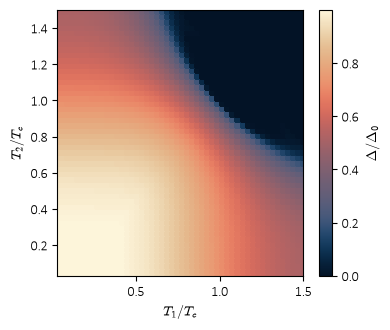

Converged: 2500 / 2500
Largest residual: 9.99713665805757e-06
Largest iteration count: 4500


In [92]:
z = da / d0

h = 0.85
fig, ax = plt.subplots(figsize=(4, h * 4))

im = ax.pcolormesh(
    tn,
    tn,
    z,
    shading="auto",
    cmap=cmaps.lipari,
    vmin=0.0,
)
im.set_edgecolor("face")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label(r"$\Delta/\Delta_0$", rotation=90, labelpad=5)

ax.set_xlabel(r"$T_1/T_c$")
ax.set_ylabel(r"$T_2/T_c$")
ax.set_xlim(tn.min(), tn.max())
ax.set_ylim(tn.min(), tn.max())

plt.tight_layout()
# plt.savefig("EI_V=3_G=2_tb2d_prodbath_gapcmap_jax.pdf")
plt.show()

print("Converged:", np.count_nonzero(ok), "/", ok.size)
print("Largest residual:", np.nanmax(er))
print("Largest iteration count:", np.max(it))